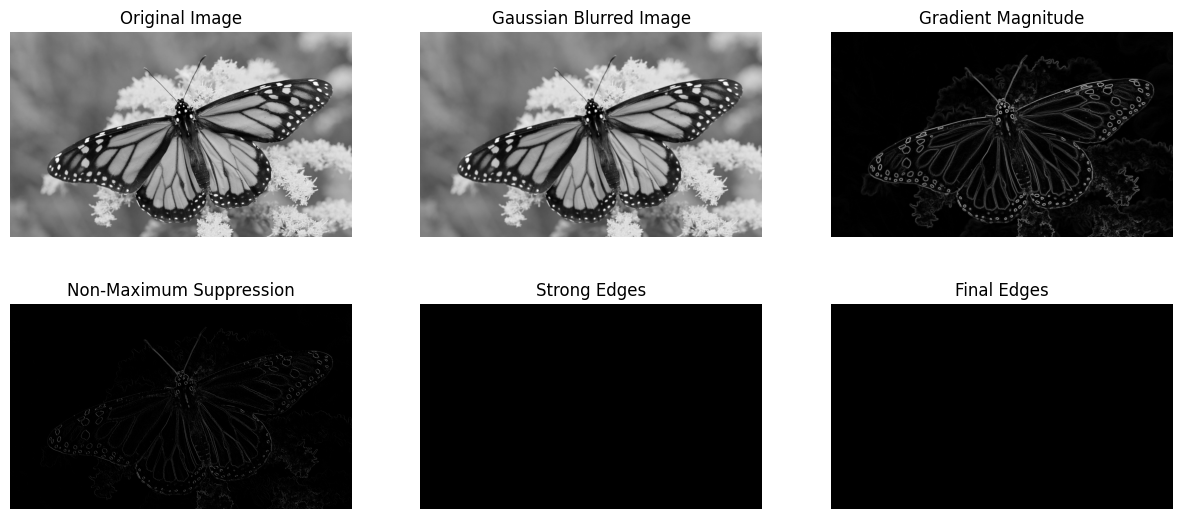

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def gaussian_blur(image, kernel_size=5, sigma=1.0):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)

def roberts_gradient(image):
    kernel_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
    kernel_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)

    grad_x = cv2.filter2D(image, -1, kernel_x)
    grad_y = cv2.filter2D(image, -1, kernel_y)

    grad_mag = cv2.magnitude(grad_x, grad_y)
    grad_dir = cv2.phase(grad_x, grad_y, angleInDegrees=True)

    return grad_mag, grad_dir

def non_maximum_suppression(grad_mag, grad_dir):
    rows, cols = grad_mag.shape
    output = np.zeros_like(grad_mag)

    grad_dir = np.round(grad_dir) % 180

    for i in range(1, rows-1):
        for j in range(1, cols-1):
            angle = grad_dir[i, j]
            if (0 <= angle < 45) or (135 <= angle < 180):
                p1, p2 = grad_mag[i, j+1], grad_mag[i, j-1]
            elif (45 <= angle < 90) or (90 <= angle < 135):
                p1, p2 = grad_mag[i+1, j-1], grad_mag[i-1, j+1]

            if grad_mag[i, j] >= p1 and grad_mag[i, j] >= p2:
                output[i, j] = grad_mag[i, j]
            else:
                output[i, j] = 0

    return output

def double_thresholding(grad_mag, low_threshold, high_threshold):
    strong_edges = np.zeros_like(grad_mag)
    weak_edges = np.zeros_like(grad_mag)

    strong_edges[grad_mag >= high_threshold] = 1
    weak_edges[(grad_mag >= low_threshold) & (grad_mag < high_threshold)] = 1

    return strong_edges, weak_edges

def hysteresis(strong_edges, weak_edges):
    rows, cols = strong_edges.shape
    final_edges = np.copy(strong_edges)

    for i in range(1, rows-1):
        for j in range(1, cols-1):
            if weak_edges[i, j] == 1:
                if np.any(strong_edges[i-1:i+2, j-1:j+2]):
                    final_edges[i, j] = 1

    return final_edges

def canny_edge_detection(image, low_threshold=50, high_threshold=150, kernel_size=5, sigma=1.0):
    image = np.float32(image)
    blurred_image = gaussian_blur(image, kernel_size, sigma)

    grad_mag, grad_dir = roberts_gradient(blurred_image)

    nms_edges = non_maximum_suppression(grad_mag, grad_dir)

    strong_edges, weak_edges = double_thresholding(nms_edges, low_threshold, high_threshold)

    final_edges = hysteresis(strong_edges, weak_edges)

    steps = [
        ("Original Image", image),
        ("Gaussian Blurred Image", blurred_image),
        ("Gradient Magnitude", grad_mag),
        ("Non-Maximum Suppression", nms_edges),
        ("Strong Edges", strong_edges),
        ("Final Edges", final_edges)
    ]

    plt.figure(figsize=(15, 10))
    for i, (title, img) in enumerate(steps, 1):
        plt.subplot(3, 3, i)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

image_path = "/content/Monarch_CV 7.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
canny_edge_detection(image)


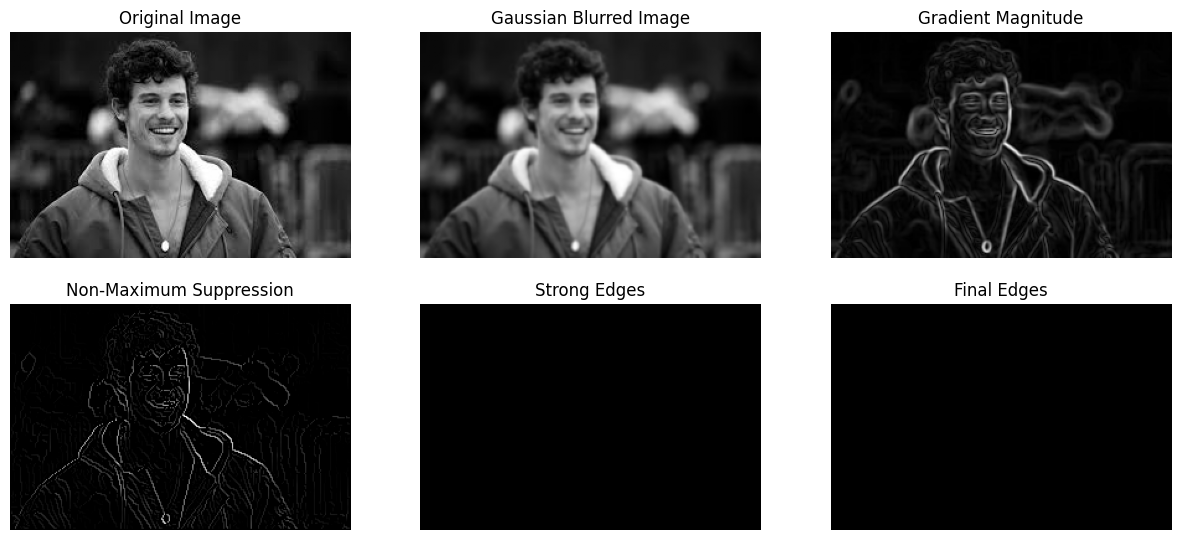

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def gaussian_blur(image, kernel_size=5, sigma=1.0):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)

def roberts_gradient(image):
    kernel_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
    kernel_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)

    grad_x = cv2.filter2D(image, -1, kernel_x)
    grad_y = cv2.filter2D(image, -1, kernel_y)

    grad_mag = cv2.magnitude(grad_x, grad_y)
    grad_dir = cv2.phase(grad_x, grad_y, angleInDegrees=True)

    return grad_mag, grad_dir

def non_maximum_suppression(grad_mag, grad_dir):
    rows, cols = grad_mag.shape
    output = np.zeros_like(grad_mag)

    grad_dir = np.round(grad_dir) % 180

    for i in range(1, rows-1):
        for j in range(1, cols-1):
            angle = grad_dir[i, j]
            if (0 <= angle < 45) or (135 <= angle < 180):
                p1, p2 = grad_mag[i, j+1], grad_mag[i, j-1]
            elif (45 <= angle < 90) or (90 <= angle < 135):
                p1, p2 = grad_mag[i+1, j-1], grad_mag[i-1, j+1]

            if grad_mag[i, j] >= p1 and grad_mag[i, j] >= p2:
                output[i, j] = grad_mag[i, j]
            else:
                output[i, j] = 0

    return output

def double_thresholding(grad_mag, low_threshold, high_threshold):
    strong_edges = np.zeros_like(grad_mag)
    weak_edges = np.zeros_like(grad_mag)

    strong_edges[grad_mag >= high_threshold] = 1
    weak_edges[(grad_mag >= low_threshold) & (grad_mag < high_threshold)] = 1

    return strong_edges, weak_edges

def hysteresis(strong_edges, weak_edges):
    rows, cols = strong_edges.shape
    final_edges = np.copy(strong_edges)

    for i in range(1, rows-1):
        for j in range(1, cols-1):
            if weak_edges[i, j] == 1:
                if np.any(strong_edges[i-1:i+2, j-1:j+2]):
                    final_edges[i, j] = 1

    return final_edges

def canny_edge_detection(image, low_threshold=50, high_threshold=150, kernel_size=5, sigma=1.0):
    image = np.float32(image)
    blurred_image = gaussian_blur(image, kernel_size, sigma)

    grad_mag, grad_dir = roberts_gradient(blurred_image)

    nms_edges = non_maximum_suppression(grad_mag, grad_dir)

    strong_edges, weak_edges = double_thresholding(nms_edges, low_threshold, high_threshold)

    final_edges = hysteresis(strong_edges, weak_edges)

    steps = [
        ("Original Image", image),
        ("Gaussian Blurred Image", blurred_image),
        ("Gradient Magnitude", grad_mag),
        ("Non-Maximum Suppression", nms_edges),
        ("Strong Edges", strong_edges),
        ("Final Edges", final_edges)
    ]

    plt.figure(figsize=(15, 10))
    for i, (title, img) in enumerate(steps, 1):
        plt.subplot(3, 3, i)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

image_path = "/content/Shawn_CV 7.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
canny_edge_detection(image)


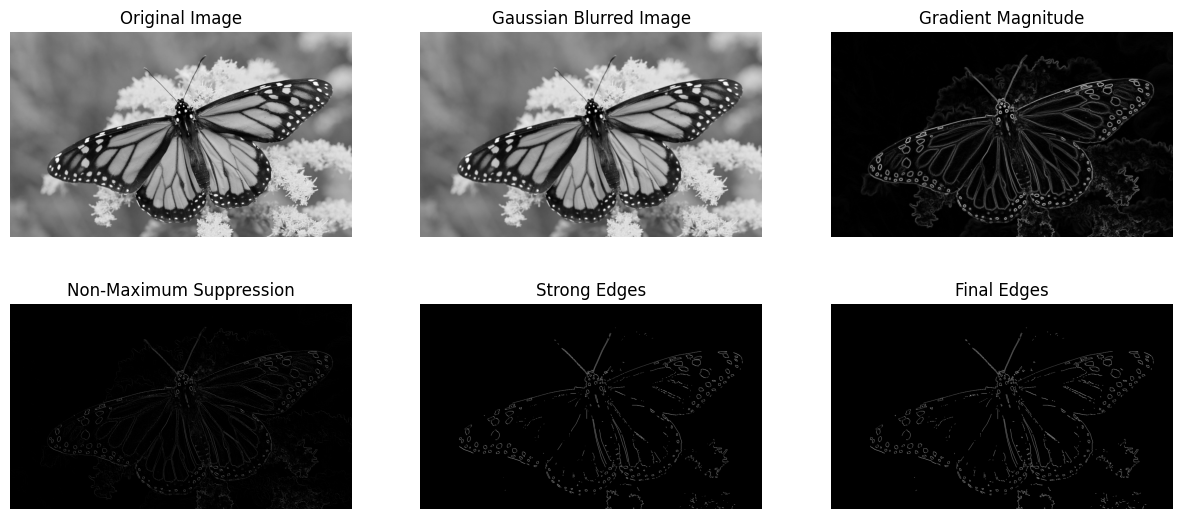

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def gaussian_blur(image, kernel_size=5, sigma=1.0):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)

def prewitt_gradient(image):
    kernel_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
    kernel_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)

    grad_x = cv2.filter2D(image, -1, kernel_x)
    grad_y = cv2.filter2D(image, -1, kernel_y)

    grad_mag = cv2.magnitude(grad_x, grad_y)
    grad_dir = cv2.phase(grad_x, grad_y, angleInDegrees=True)

    return grad_mag, grad_dir

def non_maximum_suppression(grad_mag, grad_dir):
    rows, cols = grad_mag.shape
    output = np.zeros_like(grad_mag)

    grad_dir = np.round(grad_dir) % 180

    for i in range(1, rows-1):
        for j in range(1, cols-1):
            angle = grad_dir[i, j]
            if (0 <= angle < 45) or (135 <= angle < 180):
                p1, p2 = grad_mag[i, j+1], grad_mag[i, j-1]
            elif (45 <= angle < 90) or (90 <= angle < 135):
                p1, p2 = grad_mag[i+1, j-1], grad_mag[i-1, j+1]

            if grad_mag[i, j] >= p1 and grad_mag[i, j] >= p2:
                output[i, j] = grad_mag[i, j]
            else:
                output[i, j] = 0

    return output

def double_thresholding(grad_mag, low_threshold, high_threshold):
    strong_edges = np.zeros_like(grad_mag)
    weak_edges = np.zeros_like(grad_mag)

    strong_edges[grad_mag >= high_threshold] = 1
    weak_edges[(grad_mag >= low_threshold) & (grad_mag < high_threshold)] = 1

    return strong_edges, weak_edges

def hysteresis(strong_edges, weak_edges):
    rows, cols = strong_edges.shape
    final_edges = np.copy(strong_edges)

    for i in range(1, rows-1):
        for j in range(1, cols-1):
            if weak_edges[i, j] == 1:
                if np.any(strong_edges[i-1:i+2, j-1:j+2]):
                    final_edges[i, j] = 1

    return final_edges

def canny_edge_detection(image, low_threshold=50, high_threshold=150, kernel_size=5, sigma=1.0):
    image = np.float32(image)
    blurred_image = gaussian_blur(image, kernel_size, sigma)

    grad_mag, grad_dir = prewitt_gradient(blurred_image)

    nms_edges = non_maximum_suppression(grad_mag, grad_dir)

    strong_edges, weak_edges = double_thresholding(nms_edges, low_threshold, high_threshold)

    final_edges = hysteresis(strong_edges, weak_edges)

    steps = [
        ("Original Image", image),
        ("Gaussian Blurred Image", blurred_image),
        ("Gradient Magnitude", grad_mag),
        ("Non-Maximum Suppression", nms_edges),
        ("Strong Edges", strong_edges),
        ("Final Edges", final_edges)
    ]

    plt.figure(figsize=(15, 10))
    for i, (title, img) in enumerate(steps, 1):
        plt.subplot(3, 3, i)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

image_path = "/content/Monarch_CV 7.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
canny_edge_detection(image)


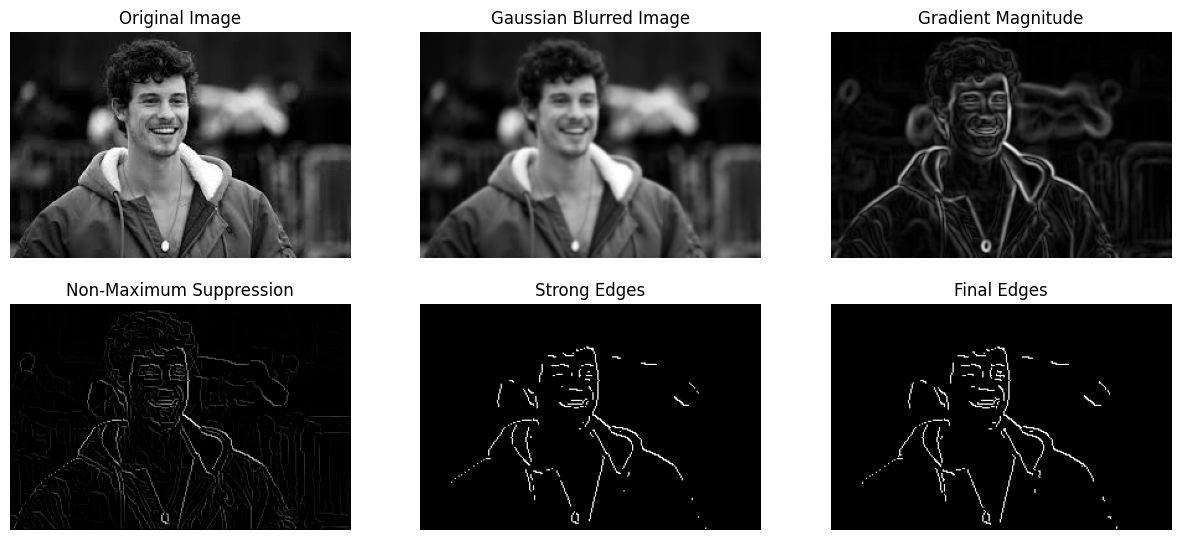

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def gaussian_blur(image, kernel_size=5, sigma=1.0):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)

def prewitt_gradient(image):
    kernel_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
    kernel_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)

    grad_x = cv2.filter2D(image, -1, kernel_x)
    grad_y = cv2.filter2D(image, -1, kernel_y)

    grad_mag = cv2.magnitude(grad_x, grad_y)
    grad_dir = cv2.phase(grad_x, grad_y, angleInDegrees=True)

    return grad_mag, grad_dir

def non_maximum_suppression(grad_mag, grad_dir):
    rows, cols = grad_mag.shape
    output = np.zeros_like(grad_mag)

    grad_dir = np.round(grad_dir) % 180

    for i in range(1, rows-1):
        for j in range(1, cols-1):
            angle = grad_dir[i, j]
            if (0 <= angle < 45) or (135 <= angle < 180):
                p1, p2 = grad_mag[i, j+1], grad_mag[i, j-1]
            elif (45 <= angle < 90) or (90 <= angle < 135):
                p1, p2 = grad_mag[i+1, j-1], grad_mag[i-1, j+1]

            if grad_mag[i, j] >= p1 and grad_mag[i, j] >= p2:
                output[i, j] = grad_mag[i, j]
            else:
                output[i, j] = 0

    return output

def double_thresholding(grad_mag, low_threshold, high_threshold):
    strong_edges = np.zeros_like(grad_mag)
    weak_edges = np.zeros_like(grad_mag)

    strong_edges[grad_mag >= high_threshold] = 1
    weak_edges[(grad_mag >= low_threshold) & (grad_mag < high_threshold)] = 1

    return strong_edges, weak_edges

def hysteresis(strong_edges, weak_edges):
    rows, cols = strong_edges.shape
    final_edges = np.copy(strong_edges)

    for i in range(1, rows-1):
        for j in range(1, cols-1):
            if weak_edges[i, j] == 1:
                if np.any(strong_edges[i-1:i+2, j-1:j+2]):
                    final_edges[i, j] = 1

    return final_edges

def canny_edge_detection(image, low_threshold=50, high_threshold=150, kernel_size=5, sigma=1.0):
    image = np.float32(image)
    blurred_image = gaussian_blur(image, kernel_size, sigma)

    grad_mag, grad_dir = prewitt_gradient(blurred_image)

    nms_edges = non_maximum_suppression(grad_mag, grad_dir)

    strong_edges, weak_edges = double_thresholding(nms_edges, low_threshold, high_threshold)

    final_edges = hysteresis(strong_edges, weak_edges)

    steps = [
        ("Original Image", image),
        ("Gaussian Blurred Image", blurred_image),
        ("Gradient Magnitude", grad_mag),
        ("Non-Maximum Suppression", nms_edges),
        ("Strong Edges", strong_edges),
        ("Final Edges", final_edges)
    ]

    plt.figure(figsize=(15, 10))
    for i, (title, img) in enumerate(steps, 1):
        plt.subplot(3, 3, i)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

image_path = "/content/Shawn_CV 7.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
canny_edge_detection(image)
